In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mdsine2 as md2
from mdsine2.names import STRNAMES
import pickle
from sklearn import linear_model as lm
import h5py

[DEBUG] Using default logger (stdout, stderr).


In [4]:
npzfile = np.load("datasets/synthetic_5sp_rel/glv_5sp.npz")
npzfile

NpzFile 'datasets/synthetic_5sp_rel/glv_5sp.npz' with keys: growth_rates, interactions, initial_mean, initial_std

In [5]:
gr = npzfile["growth_rates"]
ints = npzfile["interactions"]

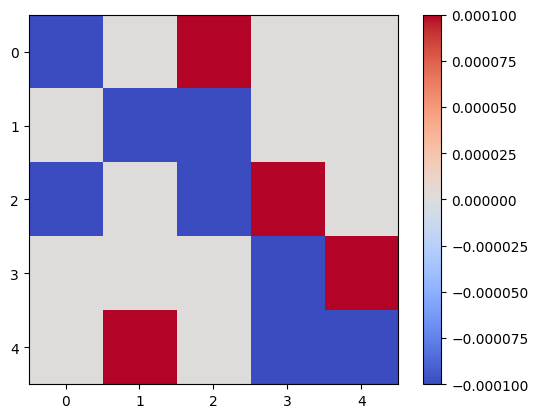

In [6]:
plt.imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
plt.colorbar()

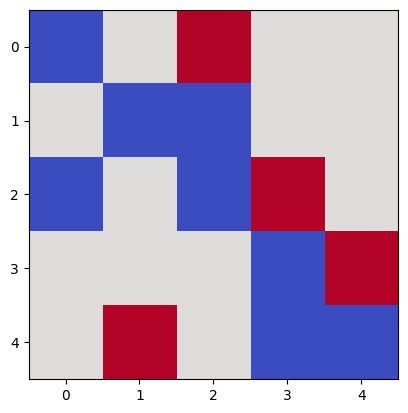

In [7]:
plt.imshow(np.sign(ints), cmap="coolwarm")

In [6]:
with open("datasets/synthetic_5sp/output/reads_25000/trial_0/low_noise/mdsine2/simulated-low/mcmc.pkl", "rb") as file:
    mcmc = pickle.load(file)

In [7]:
gr_est = md2.summary(mcmc.graph[STRNAMES.GLV_PARAMETERS].growth)["mean"]

In [8]:
gr_est

array([0.99877128, 0.8305041 , 0.7879134 , 0.91707604, 0.78163622])

In [9]:
md2.summary(mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE])["mean"]

array([5.78398003e-05, 4.81703653e-05, 7.08775198e-05, 7.04889979e-05,
       9.55286306e-05])

In [10]:
gr_est = md2.summary(mcmc.graph[STRNAMES.GROWTH_VALUE])["median"]

In [11]:
mcmc

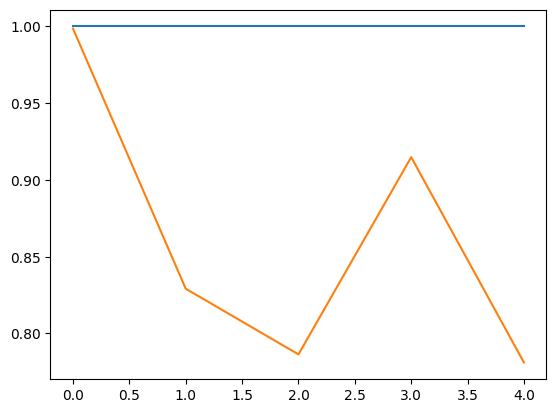

In [12]:
plt.plot(gr)
plt.plot(gr_est)

In [13]:
ints_est = md2.summary(mcmc.graph[STRNAMES.INTERACTIONS_OBJ].get_trace_from_disk())["mean"]-np.diag(md2.summary(mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE].get_trace_from_disk())["mean"])

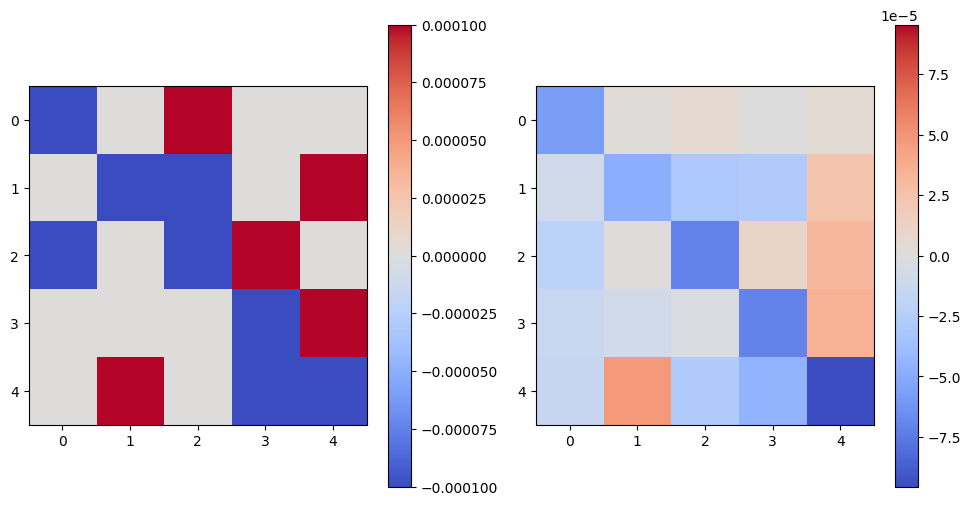

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est, cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

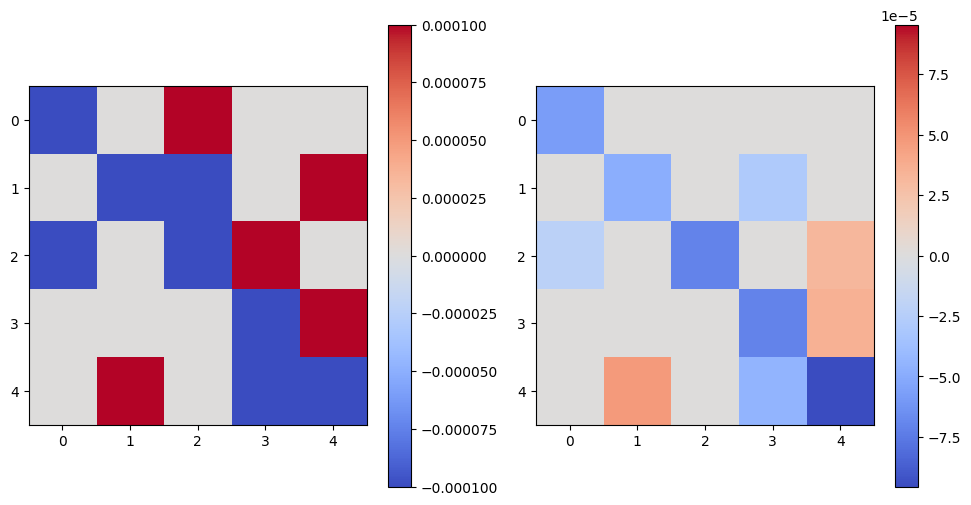

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est*(md2.generate_interation_bayes_factors_posthoc(mcmc, )>10)+np.diag(np.diag(ints_est)), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

In [21]:
from scipy.stats import spearmanr, pearsonr

In [22]:
spearmanr(gr, gr_est)

SignificanceResult(statistic=nan, pvalue=nan)

In [23]:
mcmc.graph[STRNAMES.PROCESSVAR].get_trace_from_disk().mean()

np.float64(0.06985777031580041)

In [24]:
spearmanr((ints).flatten(), (ints_est).flatten())

SignificanceResult(statistic=np.float64(0.8839916156110237), pvalue=np.float64(4.67955493170181e-09))

In [25]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.7761922789107946), pvalue=np.float64(5.107944124117271e-06))

In [26]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

SignificanceResult(statistic=np.float64(0.5901445144582854), pvalue=np.float64(0.0019009359097517135))

In [27]:
spearmanr((ints).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)+np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.7847027923341), pvalue=np.float64(3.422321885072086e-06))

In [28]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

PearsonRResult(statistic=np.float64(0.7652419489743691), pvalue=np.float64(8.343740719738588e-06))

In [29]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

PearsonRResult(statistic=np.float64(0.5985666084771772), pvalue=np.float64(0.0015724111666006889))

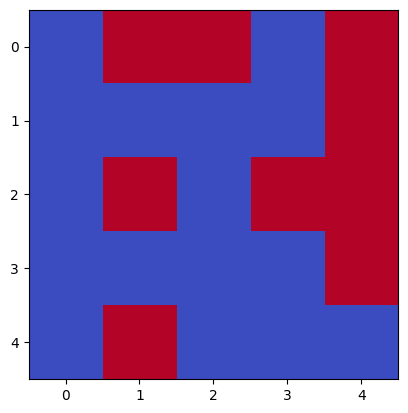

In [30]:
plt.imshow(np.sign(ints_est), cmap="coolwarm")

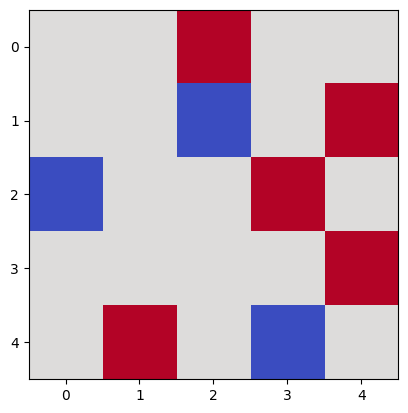

In [32]:
plt.imshow(np.sign(ints)+np.eye(5), cmap="coolwarm")

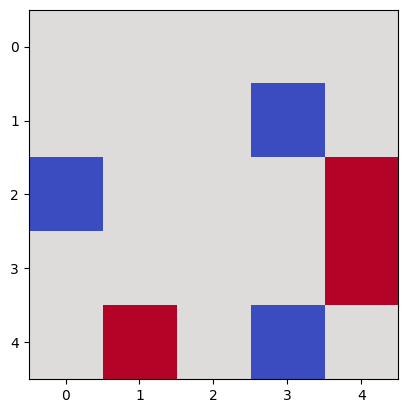

In [33]:
plt.imshow(np.sign(ints_est)*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10), cmap="coolwarm")

---

In [8]:
with open("datasets/synthetic_5sp_rel/data/trial_0/reads_100000/noise_low/subjset.pkl", "rb") as file:
    subjset = pickle.load(file)

In [9]:
list(subjset[0].qpcr.values())[0].data.mean()

np.float64(4329.025922995997)

In [10]:
t = subjset[0].times

NameError: name 'X' is not defined

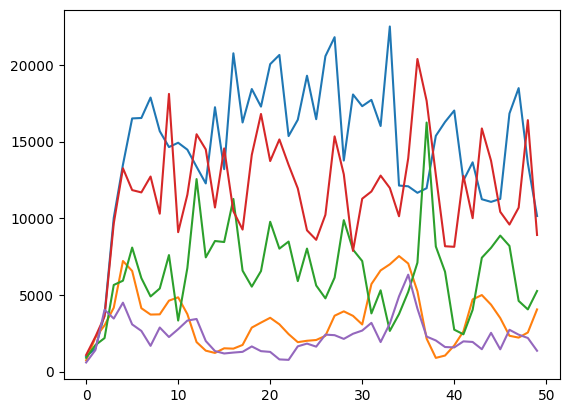

In [11]:
plt.plot(subjset[0].matrix()["abs"].T)
plt.plot(X[:26]/25000, "--")

In [267]:
reads = np.array(list(subjset[0].reads.values()))
qpcr = np.array([i.data.mean() for i in subjset[0].qpcr.values()])

X = reads*qpcr.reshape((-1,1))

dX = np.diff(X, axis=0)
X = X[:-1]

for i in range(1, 10):
    reads = np.array(list(subjset[i].reads.values()))
    qpcr = np.array([k.data.mean() for k in subjset[i].qpcr.values()])

    x = reads*qpcr.reshape((-1,1))
    dx = np.diff(x, axis=0)

    X = np.concatenate([X, x[:-1]], axis=0)
    dX = np.concatenate([dX, dx], axis=0)

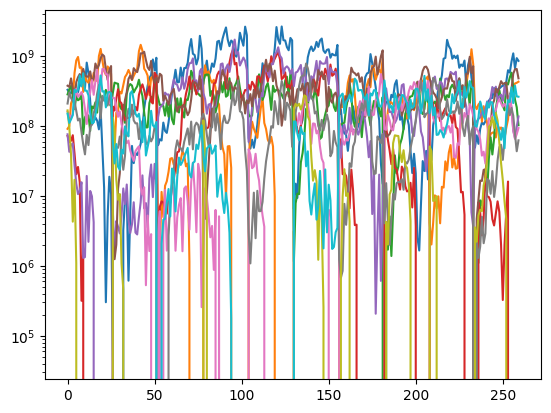

In [268]:
plt.plot(X)
plt.yscale("log")

In [269]:
reg = lm.LinearRegression(fit_intercept=False)

In [270]:
Aest = np.zeros((10,11))

for i in range(10):
    feats = np.hstack([X[i*26:(i+1)*26,[i]], X[i*26:(i+1)*26,[i]]*X[i*26:(i+1)*26]])
    reg.fit(feats, dX[i*26:(i+1)*26,i]/np.diff(t))
    Aest[i] = reg.coef_

In [271]:
reg.coef_

array([ 9.48773575e-01, -1.31326100e-11,  3.18133436e-10,  7.33752428e-10,
        2.40148463e-08, -3.55152920e-09,  2.24261245e-10,  7.63313390e-10,
        1.79321841e-10,  1.31121812e-09, -3.72888731e-09])

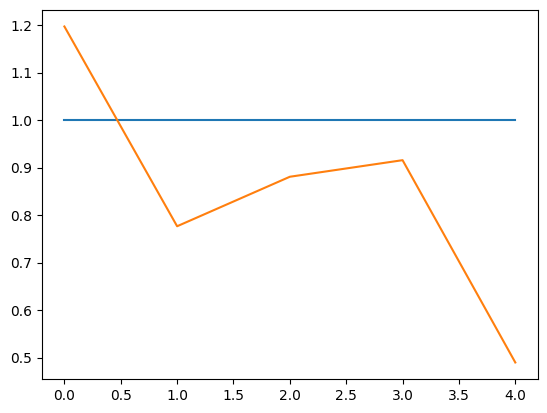

In [30]:
plt.plot(gr)
plt.plot(gr_est)
# plt.plot(Aest[:,0])

In [31]:
plt.imshow(Aest[:,1:], cmap="coolwarm", vmin=-np.max(np.abs(Aest[:,1:])), vmax=np.max(np.abs(Aest[:,1:])))
plt.colorbar()

NameError: name 'Aest' is not defined

In [32]:
spearmanr(ints.flatten(), Aest[:,1:].flatten())

NameError: name 'spearmanr' is not defined

In [14]:
traces = h5py.File("datasets/synthetic_5sp_rel/output/reads_100000/trial_0/low_noise/mdsine2/simulated-low/traces.hdf5", "r")

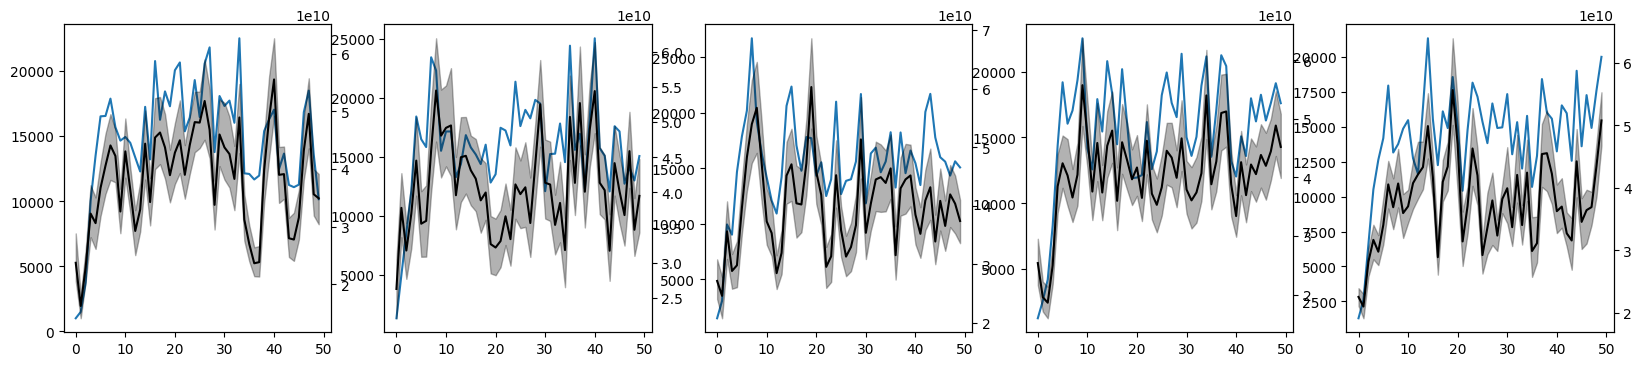

In [16]:
fig, ax = plt.subplots(1, 5, figsize=(20,4))

for i in range(5):
    ax.flatten()[i].plot(subjset[i].matrix()["abs"].T[:,0])
    ax1 = ax.flatten()[i].twinx()
    ax1.plot(md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{i}"]))["mean"].T[:,0], c="k")
    ax1.fill_between(np.arange(50), *np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{i}"]), [5,95], axis=0)[:,0], color="k", alpha=0.3)

In [17]:
def generate_interation_bayes_factors_posthoc(traces):
    '''Generates the bayes factors on an item-item level for the interactions,
    given the passed in prior. All negative indicators are set as `np.nan`s in
    the trace, so we do `~np.isnan` to get the indicators.

    Since the prior is conjugate, we can fully integrate out the prior of the
    calculation:
        bf[i,j] = (count_on[i,j] * b) / (count_off[i,j] * a)

    Parameters
    ----------
    mcmc : mdsine2.BaseMCMC
        This is the inference object containing the traces
    section : str
        This is the section of the MH samples to take the samples

    Returns
    -------
    np.ndarray((n,n), dtype=float)
        These are the bayes factors for each of the interactions on an item-item level
    '''
    # interactions = mcmc.graph[STRNAMES.INTERACTIONS_OBJ]
    # trace = interactions.get_trace_from_disk(section=section)

    trace = traces[STRNAMES.INTERACTIONS_OBJ]
    
    trace = ~ np.isnan(trace)
    cnts_1 = np.sum(trace, axis=0)
    cnts_0 = np.sum(1-trace, axis=0)

    return cnts_1/cnts_0
    
    # print(cnts_1)
    # print()
    # print(cnts_0)

    # a = mcmc.graph[STRNAMES.CLUSTER_INTERACTION_INDICATOR_PROB].prior.a.value
    # b = mcmc.graph[STRNAMES.CLUSTER_INTERACTION_INDICATOR_PROB].prior.b.value

    # return (cnts_1 * b) / (cnts_0 * a)

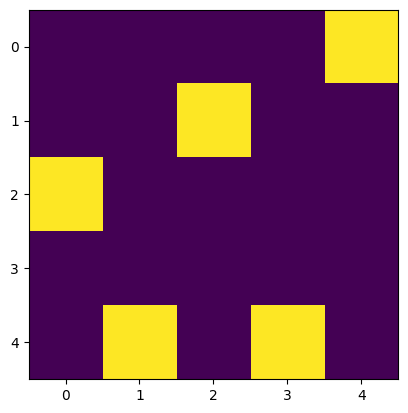

In [18]:
plt.imshow(generate_interation_bayes_factors_posthoc(traces)>10)

In [39]:
plt.imshow(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)

NameError: name 'mcmc' is not defined

---

In [40]:
import h5py

In [19]:
traces = h5py.File("datasets/synthetic_5sp_rel/output/reads_100000/trial_0/low_noise/mdsine2/simulated-low/traces.hdf5", "r")

In [20]:
traces.keys()

<KeysViewHDF5 ['Cluster interaction indicator parameter', 'Cluster interaction probability', 'Growth parameter', 'Interactions object', 'Latent trajectory parameter_subj_0', 'Latent trajectory parameter_subj_1', 'Latent trajectory parameter_subj_2', 'Latent trajectory parameter_subj_3', 'Latent trajectory parameter_subj_4', 'Mean parameter for the normal prior of the interaction parameter', 'Mean parameter for the truncated normal prior of the growth parameter', 'Mean parameter for the truncated normal prior of the self-interaction parameter', 'Process Variance parameter', 'Self interaction parameter', 'Variance parameter for the normal prior of the interaction parameter']>

In [21]:
gr_est = md2.summary(np.array(traces[STRNAMES.GROWTH_VALUE]))["mean"]

In [22]:
ints_est = md2.summary(np.array(traces[STRNAMES.INTERACTIONS_OBJ]))["mean"]-np.diag(md2.summary(np.array(traces[STRNAMES.SELF_INTERACTION_VALUE]))["mean"])

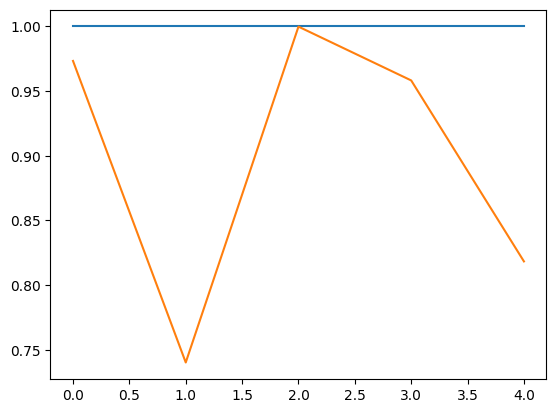

In [23]:
plt.plot(gr)
plt.plot(gr_est)

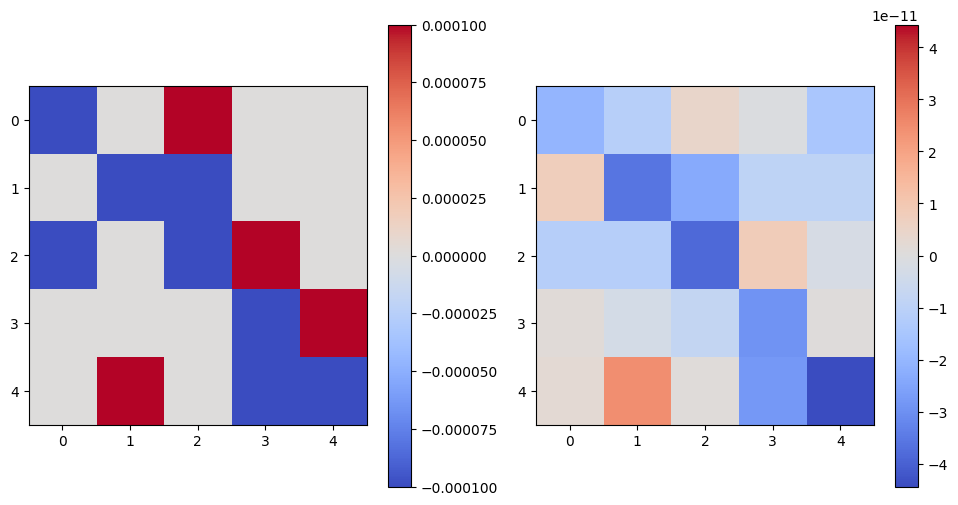

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est, cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

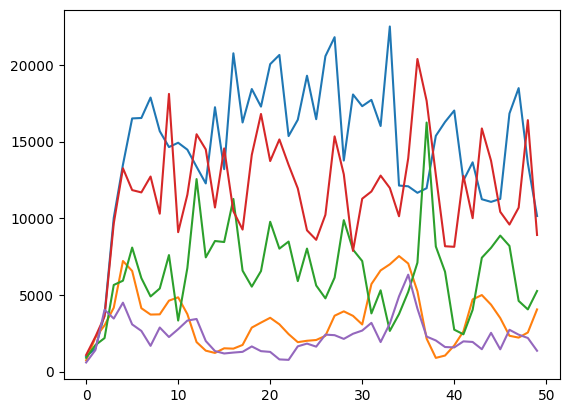

In [25]:
plt.plot(subjset[0].matrix()["abs"].T)

In [48]:
subjset[0].read_depth()

array([25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000,
       25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000,
       25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000,
       25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000,
       25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000, 25000,
       25000, 25000, 25000, 25000, 25000, 25000])

In [49]:
npzfile["initial_mean"]

array(500.)

In [50]:
npzfile["initial_std"]

array(50.)

In [51]:
list(subjset[0].qpcr.values())[0].data

array([2442.56456389, 2450.20654069, 2460.58532473])

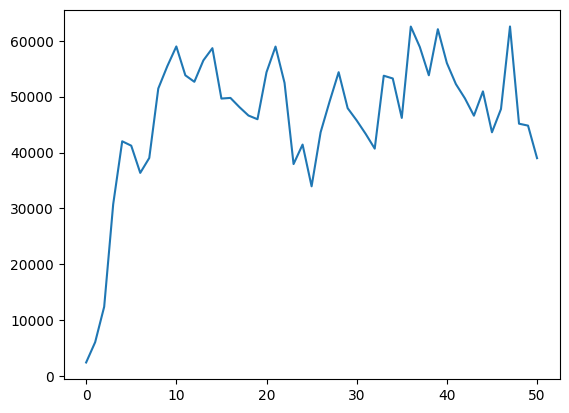

In [52]:
plt.plot([i.data.mean() for i in subjset[0].qpcr.values()])

In [53]:
np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{i}"]).shape

(15000, 5, 51)

In [54]:
np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{i}"]), [25,75], axis=0).shape

(2, 5, 51)

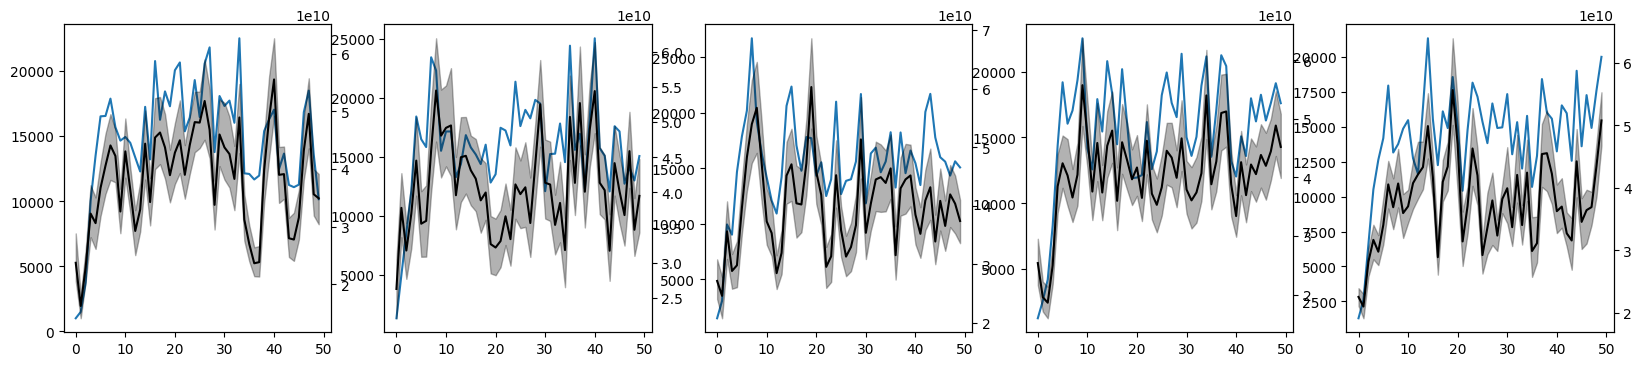

In [32]:
fig, ax = plt.subplots(1, 5, figsize=(20,4))

for i in range(5):
    ax.flatten()[i].plot(subjset[i].matrix()["abs"].T[:,0])
    ax1 = ax.flatten()[i].twinx()
    ax1.plot(md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{i}"]))["mean"].T[:,0], c="k")
    ax1.fill_between(np.arange(50), *np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{i}"]), [5,95], axis=0)[:,0], color="k", alpha=0.3)

In [40]:
md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i]

array([2.37114231e+10, 1.62147679e+10, 2.29417840e+10, 3.22593942e+10,
       3.06003685e+10, 3.67169197e+10, 4.05786598e+10, 4.40925911e+10,
       4.22645119e+10, 3.26175788e+10, 4.30601152e+10, 3.63912628e+10,
       2.92372637e+10, 3.29772036e+10, 4.44021880e+10, 3.42580284e+10,
       4.54658042e+10, 4.63396373e+10, 4.37575320e+10, 3.89253491e+10,
       4.28380352e+10, 4.49875144e+10, 3.89949386e+10, 4.41817304e+10,
       4.81421673e+10, 4.80580195e+10, 5.18134559e+10, 4.68065844e+10,
       3.37753162e+10, 4.59938608e+10, 4.37460902e+10, 4.26049746e+10,
       3.82828855e+10, 4.89542322e+10, 3.12042976e+10, 2.69638708e+10,
       2.36307681e+10, 2.38239989e+10, 3.97956905e+10, 4.88347479e+10,
       5.55523439e+10, 3.89901322e+10, 3.91120394e+10, 2.79769841e+10,
       2.77507431e+10, 3.15568478e+10, 4.32039321e+10, 4.95833649e+10,
       3.56118643e+10, 3.49215963e+10])

In [42]:
subjset[0].matrix()["abs"][i].mean()

np.float64(14813.414848233748)

In [47]:
np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{i}"]), [5,95], axis=0)[:,0]

array([[2.11022647e+10, 1.91327540e+10, 2.58140648e+10, 2.85711980e+10,
        2.76260344e+10, 3.09435562e+10, 3.66928171e+10, 3.33751738e+10,
        3.68586578e+10, 3.19684747e+10, 3.43822325e+10, 3.66225348e+10,
        3.82459285e+10, 3.97594706e+10, 4.46762382e+10, 3.79752933e+10,
        2.61056067e+10, 3.77973628e+10, 3.95591073e+10, 5.00462243e+10,
        3.94186201e+10, 2.74870852e+10, 3.26703552e+10, 4.03094687e+10,
        3.72339619e+10, 2.62754544e+10, 2.93334141e+10, 3.08456513e+10,
        2.98934269e+10, 3.59334768e+10, 3.43343403e+10, 3.06805656e+10,
        3.76324363e+10, 3.09161888e+10, 3.78841228e+10, 2.57456616e+10,
        2.80419380e+10, 4.01345216e+10, 3.94655557e+10, 3.73751315e+10,
        3.27448871e+10, 3.36078547e+10, 3.05889460e+10, 2.68900715e+10,
        3.84807256e+10, 3.02044578e+10, 3.10896517e+10, 3.40201304e+10,
        3.85745443e+10, 4.67511900e+10],
       [2.39393438e+10, 2.30228695e+10, 3.03476806e+10, 3.40852322e+10,
        3.24165405e+10,

In [58]:
np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]).std(0).shape

(5, 50)

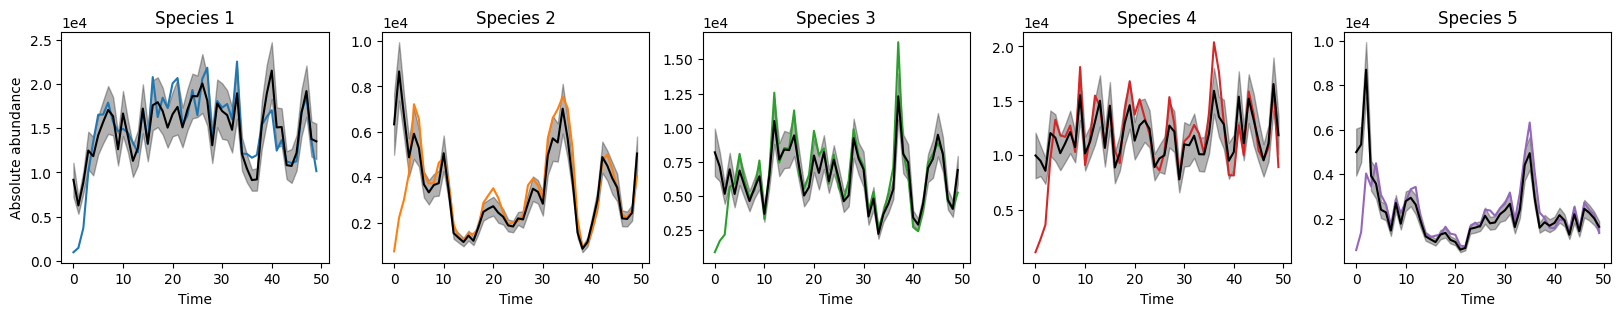

In [62]:
fig, ax = plt.subplots(1, 5, figsize=(20,3))
plt.subplots_adjust(hspace=0.5)

for i in range(5):
    ax[i].plot(subjset[0].times, subjset[0].matrix()["abs"][i], c=f"C{i}")
    shift = subjset[0].matrix()["abs"][i].mean()/md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i].mean()
    ax[i].plot(subjset[0].times, shift*md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i], c="k")
    # ax[i].fill_between(subjset[0].times, *np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]), [2.275,97.725], axis=0)[:,i]*shift, color="k", alpha=0.3)
    ax[i].fill_between(subjset[0].times, shift*(md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i]-np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]).std(0)[i]*2), shift*(md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i]+np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]).std(0)[i]*2), color="k", alpha=0.3)
    # ax[i].plot(subjset[0].times, t_aug, shift*np.exp(ms_list[0][1:,i]), c="k")
    # ax[i].fill_between(t_aug, shift*np.exp(ms_list[0][1:,i]-Ps_list[0][1:,i,i]**0.5*2), shift*np.exp(ms_list[0][1:,i]+Ps_list[0][1:,i,i]**0.5*2), color="k", alpha=0.3)
    ax[i].ticklabel_format(axis="y", style="sci", scilimits=[0,0])
    ax[i].set_title(f"Species {i+1}")
    ax[i].set_xlabel("Time")
    if i==0:
        ax[i].set_ylabel("Absolute abundance")

plt.savefig("estimate_abundance_mdsine.svg", format="svg", bbox_inches="tight")

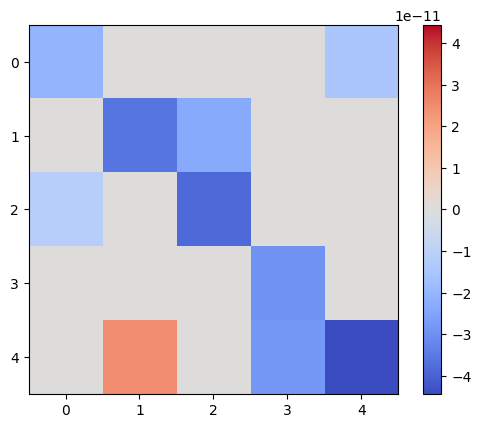

In [63]:
# plt.imshow(p_est2[5:30].reshape((5,5)), cmap="coolwarm", vmin=-np.max(np.abs(p_est2[5:30])), vmax=np.max(np.abs(p_est2[5:30])))
plt.imshow(ints_est*(generate_interation_bayes_factors_posthoc(traces)>=10.)+np.diag(np.diag(ints_est)), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))

plt.colorbar()
plt.savefig("estimated_interactions_mdsine.svg", format="svg", bbox_inches="tight")

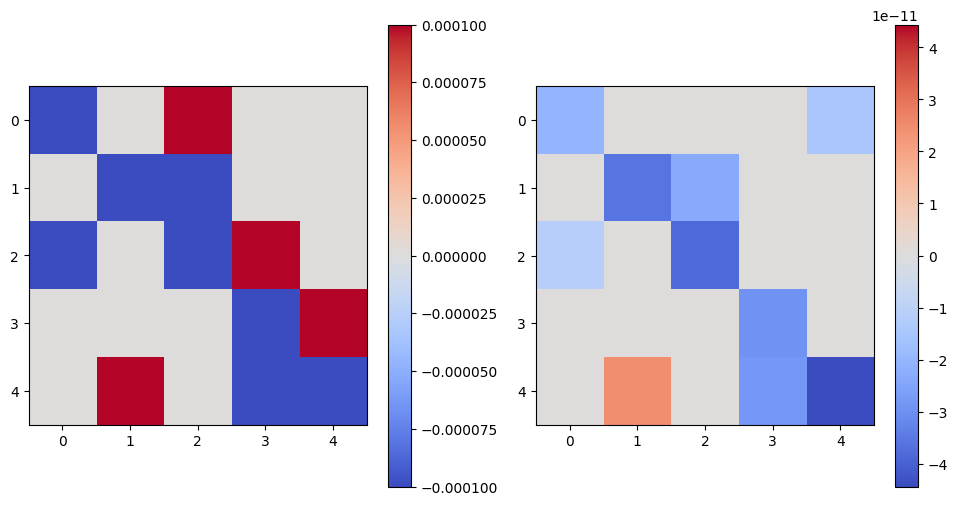

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est*(generate_interation_bayes_factors_posthoc(traces)>=10.)+np.diag(np.diag(ints_est)), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

In [20]:
from scipy.stats import spearmanr, pearsonr

In [21]:
spearmanr(gr, gr_est)

SignificanceResult(statistic=np.float64(-0.1515151515151515), pvalue=np.float64(0.6760651759978539))

In [128]:
mcmc.graph[STRNAMES.PROCESSVAR].get_trace_from_disk().mean()

np.float64(0.19012891907758775)

In [36]:
spearmanr((ints).flatten(), (ints_est).flatten())

SignificanceResult(statistic=np.float64(0.66712359197748), pvalue=np.float64(3.4998005438560444e-14))

In [37]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.5535974798769446), pvalue=np.float64(2.3167629557750118e-09))

In [57]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

SignificanceResult(statistic=np.float64(0.747881320660978), pvalue=np.float64(3.888298164136079e-19))

In [58]:
spearmanr((ints).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)+np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.8226865066386722), pvalue=np.float64(8.93653331197679e-26))

In [59]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

PearsonRResult(statistic=np.float64(0.7400269014111068), pvalue=np.float64(1.4164075709595746e-18))

In [60]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

PearsonRResult(statistic=np.float64(0.7883897417554289), pvalue=np.float64(2.1272455995785715e-22))

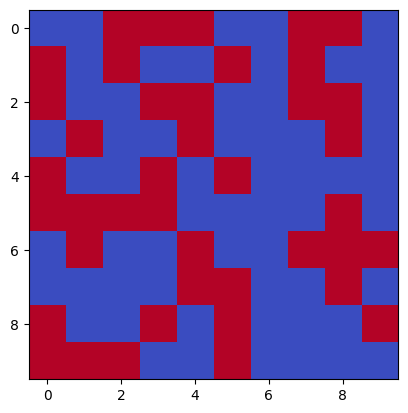

In [61]:
plt.imshow(np.sign(ints_est), cmap="coolwarm")

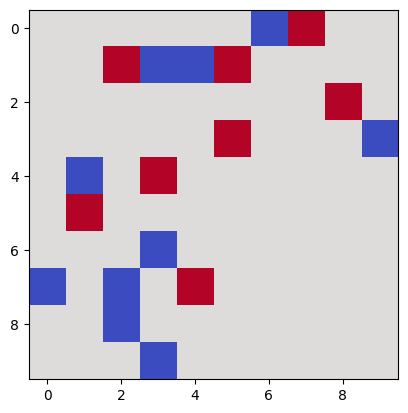

In [93]:
plt.imshow(np.sign(ints)+np.eye(10), cmap="coolwarm")

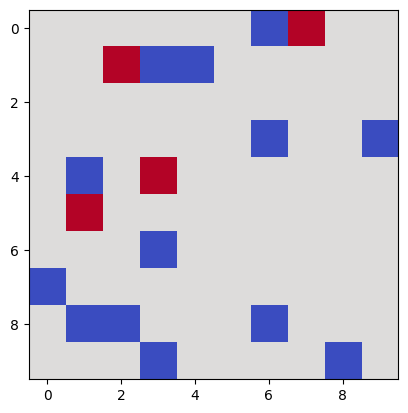

In [74]:
plt.imshow(np.sign(ints_est)*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10), cmap="coolwarm")